# 1D Obstacle Solver

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import svd
from google.colab import files
# ----------------------------
# Parameters
# ----------------------------
N = 100                         # Number of RBF centers
T = 2
M = T * N                      # Number of collocation points


max_iter = 50000
tau = 1e-15                   # SVD truncation tolerance factor
tol = 1e-10                   # ADMM convergence tolerance

problem = '1'

if problem == '1':
    mu = 300
    rho = 45
elif problem == '2':
    mu = 2.5e4
    rho = 250



# formula to find c.
gamma_N = (95/np.pi) * (T/N) * np.sqrt(2 * np.log(1 + tau**(-2)))
c_formula = np.pi/(T * np.sqrt( 2 * np.log(1 + tau**(-2))))
c = np.minimum(1, gamma_N * c_formula)


c = 0.95              # current best c value.
b = c * N             # Shape parameter for Gaussian RBF





# ----------------------------
# Domain and Obstacles
# ----------------------------
x = np.linspace(0, 1, M)      # Collocation points
centers = np.linspace(0, 1, N)      # RBF centers
dx = x[1] - x[0]              # Uniform spacing

# --- phi1: Single pump obstacle ---
def psi1(x):
    x = np.asarray(x)
    y = np.zeros_like(x)

    mask1 = (x >= 0) & (x <= 0.25)
    mask2 = (x > 0.25) & (x <= 0.5)
    mask3 = (x > 0.5) & (x <= 1.0)

    y[mask1] = 100 * x[mask1]**2
    y[mask2] = 100 * x[mask2] * (1 - x[mask2]) - 12.5

    x_sym = 1 - x[mask3]
    y[mask3] = np.where(
        x_sym <= 0.25,
        100 * x_sym**2,
        100 * x_sym * (1 - x_sym) - 12.5
    )
    return y

def u1_exact(x):
    x = np.asarray(x)
    y = np.zeros_like(x)

    x_thresh = 1 / (2 * np.sqrt(2))

    mask1 = (x >= 0) & (x <= x_thresh)
    mask2 = (x > x_thresh) & (x <= 0.5)
    mask3 = (x > 0.5) & (x <= 1.0)

    y[mask1] = (100 - 50 * np.sqrt(2)) * x[mask1]
    y[mask2] = 100 * x[mask2] * (1 - x[mask2]) - 12.5

    x_sym = 1 - x[mask3]
    y[mask3] = np.where(
        x_sym <= x_thresh,
        (100 - 50 * np.sqrt(2)) * x_sym,
        100 * x_sym * (1 - x_sym) - 12.5
    )
    return y

# # --- phi2: Two pumps obstacle ---
def psi2(x):
    y = np.zeros_like(x)
    mask1 = (x >= 0) & (x <= 0.25)
    mask2 = (x > 0.25) & (x <= 0.5)
    mask3 = (x > 0.5) & (x <= 1)

    y[mask1] = 10 * np.sin(2 * np.pi * x[mask1])
    y[mask2] = 5 * np.cos(np.pi * (4 * x[mask2] - 1)) + 5

    # Symmetry for last interval
    x_sym = 1 - x[mask3]
    y[mask3] = np.where(
        x_sym <= 0.25,
        10 * np.sin(2 * np.pi * x_sym),
        5 * np.cos(np.pi * (4 * x_sym - 1)) + 5
    )
    return y

# Exact solution u2 for phi2 obstacle (alternative)
def u2_exact(x):
    y = np.zeros_like(x)
    mask1 = (x >= 0) & (x <= 0.25)
    mask2 = (x > 0.25) & (x <= 0.5)
    mask3 = (x > 0.5) & (x <= 1)

    y[mask1] = 10 * np.sin(2 * np.pi * x[mask1])
    y[mask2] = 10

    # Symmetry for last interval
    x_sym = 1 - x[mask3]
    y[mask3] = np.where(
        x_sym <= 0.25,
        10 * np.sin(2 * np.pi * x_sym),
        10
    )
    return y


# --- Choose which obstacle to use ---


if problem == '1':
    psi = psi1(x)
    u_true = u1_exact(x)
elif problem == '2':
    psi = psi2(x)
    u_true = u2_exact(x)

# Boundary targets
u0 = u_true[0]
u1 = u_true[-1]

# ----------------------------
# Radial Basis Functions (Gaussian)
# ----------------------------
def rbf(x, centers):
    return np.exp(-b**2 * (x[:, None] - centers[None, :])**2)

def drbf(x, centers):
    return -2 * b**2 * (x[:, None] - centers[None, :]) * rbf(x, centers)

Phi_raw = rbf(x, centers)
Phi = Phi_raw / np.sqrt(N)         # Normalized RBF matrix
dPhi = drbf(x, centers) / np.sqrt(N)

A1 = dPhi.T @ dPhi * dx            # Stiffness matrix

# Boundary penalty parameters
beta = 3e5
h_bc = 1e-6

idx_bc0 = np.where(x <= h_bc)[0]
idx_bc1 = np.where(x >= 1 - h_bc)[0]

Phi_bc0 = Phi[idx_bc0, :]
Phi_bc1 = Phi[idx_bc1, :]

u0_vec = u0 * np.ones(len(idx_bc0))
u1_vec = u1 * np.ones(len(idx_bc1))

W0 = dx * np.eye(len(idx_bc0))
W1 = dx * np.eye(len(idx_bc1))

A = A1 + beta * (Phi_bc0.T @ W0 @ Phi_bc0 + Phi_bc1.T @ W1 @ Phi_bc1) # constructing A matrix

lhs = A + rho * (Phi.T @ Phi) # lhs in the w-minimization subproblem.

U, S, VT = svd(lhs, full_matrices=False)

svd_tol = tau * np.max(S)
S_inv = np.where(S > svd_tol, 1 / S, 0)

def svd_solve(U, S_inv, VT, b):
    return VT.T @ (S_inv * (U.T @ b))

# ADMM initialization
w = np.zeros(N)
v = Phi @ w
z = np.zeros(M)

# --- Initialize storage for residuals ---
primal_errors = []
dual_errors = []
iter_store = []
l2_errors = []


for it in range(max_iter):


    rhs = rho * Phi.T @ (v - z) + beta * (Phi_bc0.T @ W0 @ u0_vec + Phi_bc1.T @ W1 @ u1_vec) # rhs in the w-minimization subproblem
    w_new = svd_solve(U, S_inv, VT, rhs) # solve with truncation SVD.

    # v-minimization subproblem.
    ratio = mu * dx / rho
    v_new = np.where(Phi @ w_new + z < psi, np.maximum(Phi @ w_new + z - ratio, psi), Phi @ w_new + z)
    # dual variable update
    z_new = z + (Phi @ w_new - v_new)





    # Calculate the primal and dual relative error.
    r_k = Phi @ w_new - v_new # primal residuals
    s_k = rho * Phi.T @ (v_new - v) # dual residuals

    norm_u = np.linalg.norm(Phi @ w_new, 2)
    norm_v = np.linalg.norm(v_new, 2)
    norm_s = np.linalg.norm(s_k, 2)

    primal_res = np.linalg.norm(r_k, 2)/max(norm_u, norm_v, tol)
    dual_res = np.linalg.norm(s_k, 2) / max(np.linalg.norm(rho * Phi.T @ z, 2), tol)


    # --- Store residuals ---
    primal_errors.append(primal_res)
    dual_errors.append(dual_res)

    u_pred = Phi @ w_new
    l2_error = np.linalg.norm(u_pred - u_true)**2/np.linalg.norm(u_true)**2
    l2_errors.append(l2_error)

    if (it % 1000 == 0) or (primal_res < tol and dual_res < tol) or (it == max_iter):
        iter_store.append(it)
        print(f"Iteration {it}: Primal residual = {primal_res:.3e}, Dual residual = {dual_res:.3e}, L2 error = {l2_error:.3e}")

    if primal_res < tol and dual_res < tol:
        print(f"ADMM converged at iteration {it}")
        break

    # Update the (w,v,z)-variable in the ADMM
    w, v, z = w_new, v_new, z_new

u_final = Phi @ w

Iteration 0: Primal residual = 1.000e+00, Dual residual = 1.286e+13, L2 error = 1.000e+00
Iteration 1000: Primal residual = 2.832e-07, Dual residual = 1.101e-04, L2 error = 1.692e-07
Iteration 2000: Primal residual = 1.194e-12, Dual residual = 1.803e-08, L2 error = 1.610e-07
Iteration 2596: Primal residual = 6.606e-15, Dual residual = 1.000e-10, L2 error = 1.610e-07
ADMM converged at iteration 2596


Relative L2 error = 1.610e-07


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

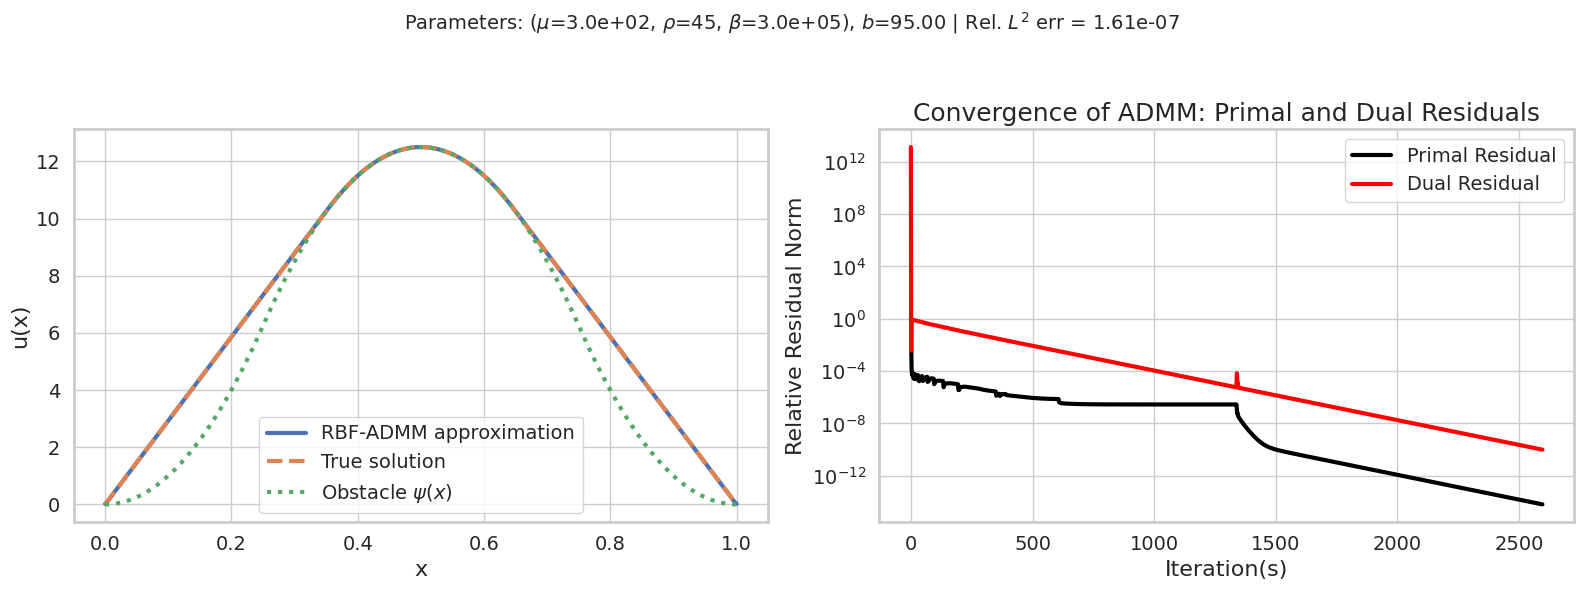

In [ ]:
# ----------------------------
# Relative L2 Error
# ----------------------------

rel_l2_error = np.linalg.norm(u_final - u_true)**2/np.linalg.norm(u_true)**2
print(f"Relative L2 error = {rel_l2_error:.3e}")

# ----------------------------
# Plot: Side-by-side Layout
# ----------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'axes.linewidth': 2,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'lines.linewidth': 3.0,
    'grid.linestyle': '-',
    'grid.alpha': 1.0,
    'figure.dpi': 100,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Approximation vs. True ---
axes[0].plot(x, u_final, label="RBF-ADMM approximation")
axes[0].plot(x, u_true, '--', label="True solution")
axes[0].plot(x, psi, ':', label="Obstacle $\psi(x)$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")
axes[0].legend()
axes[0].grid(True)
#axes[0].set_title("Approximation vs. True")

# --- Right: ADMM Residuals ---
iters = np.arange(len(primal_errors))
axes[1].plot(iters, primal_errors, label="Primal Residual", color = 'black')
axes[1].plot(iters, dual_errors, label="Dual Residual", color = 'red')
axes[1].set_yscale("log")
axes[1].set_xlabel("Iteration(s)")
axes[1].set_ylabel("Relative Residual Norm")
axes[1].legend()
axes[1].grid(True)
axes[1].set_title("Convergence of ADMM: Primal and Dual Residuals")

fig.suptitle(
    rf"Parameters: ($\mu$={mu:.1e}, $\rho$={rho}, $\beta$={beta:.1e}), $b$={b:.2f} | Rel. $L^2$ err = {rel_l2_error:.2e}",
    fontsize=14,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])


if problem == '1':
    plt.savefig('fig1_obstacle1D_single_bump.png')
    files.download('fig1_obstacle1D_single_bump.png')
elif problem == '2':
    plt.savefig('fig1_obstacle1D_two_bump.png')
    files.download('fig1_obstacle1D_two_bump.png')




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

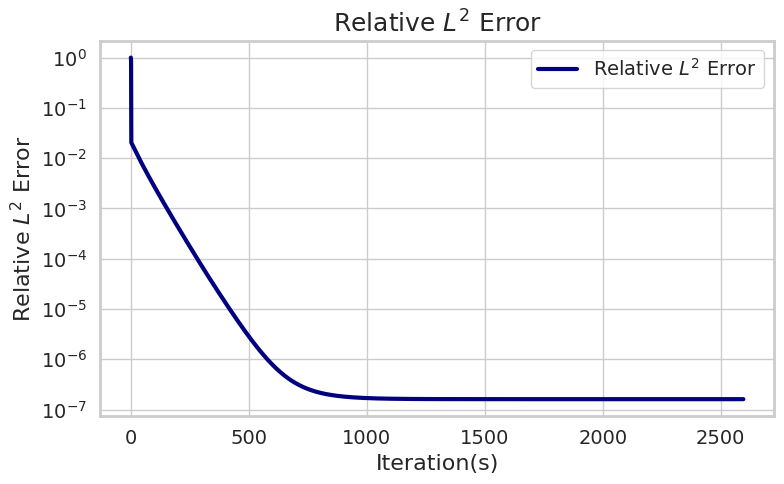

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(l2_errors)), l2_errors, label="Relative $L^2$ Error", color='navy')
plt.xlabel("Iteration(s)")
plt.ylabel("Relative $L^2$ Error")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.title("Relative $L^2$ Error")
plt.tight_layout()

if problem == '1':
    plt.savefig('fig2_obstacle1D_single_bump.png')
    files.download('fig2_obstacle1D_single_bump.png')
elif problem == '2':
    plt.savefig('fig2_obstacle1D_two_bump.png')
    files.download('fig2_obstacle1D_two_bump.png')



# Numba Version for large N

In [ ]:
"""
Gaussian-RBF ADMM (1-D obstacle) – logging & 4-sig-fig printing
---------------------------------------------------------------
* matrices:  phi, dphi
* Numba JIT only on heavy kernels (no prints inside njit)
"""

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from numba import njit

# ---------------------------------------------------------------
# 1. user parameters
# ---------------------------------------------------------------
problem  = '1'          # '1' or '2'; 1: single bumps obstacle problem, 2: 2 bump obstacles
N        = 100
T        = 2
max_iter = 50_000
tau      = 1e-15
tol      = 1e-10
mu, rho  = (300, 45) if problem == '1' else (2.5e4, 250)

c  = 0.95
b  = c * N

# ---------------------------------------------------------------
# 2. mesh, exact solution and obstacle
# ---------------------------------------------------------------
M        = T * N
x        = np.linspace(0.0, 1.0, M)
centres  = np.linspace(0.0, 1.0, N)
dx       = x[1] - x[0]

def psi1(x):
    x = np.asarray(x)
    y = np.zeros_like(x)
    m1 = x <= 0.25
    m2 = (x > 0.25) & (x <= 0.5)
    m3 = x > 0.5
    y[m1] = 100*x[m1]**2
    y[m2] = 100*x[m2]*(1-x[m2]) - 12.5
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= 0.25,
                     100*xs**2,
                     100*xs*(1-xs) - 12.5)
    return y

def u1_exact(x):
    x  = np.asarray(x)
    y  = np.zeros_like(x)
    xc = 1/(2*np.sqrt(2))
    m1 = x <= xc
    m2 = (x > xc) & (x <= 0.5)
    m3 = x > 0.5
    y[m1] = (100-50*np.sqrt(2))*x[m1]
    y[m2] = 100*x[m2]*(1-x[m2]) - 12.5
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= xc,
                     (100-50*np.sqrt(2))*xs,
                     100*xs*(1-xs) - 12.5)
    return y

def psi2(x):
    y   = np.zeros_like(x)
    m1  = x <= 0.25
    m2  = (x > 0.25) & (x <= 0.5)
    m3  = x > 0.5
    y[m1] = 10*np.sin(2*np.pi*x[m1])
    y[m2] = 5*np.cos(np.pi*(4*x[m2]-1)) + 5
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= 0.25,
                     10*np.sin(2*np.pi*xs),
                     5*np.cos(np.pi*(4*xs-1)) + 5)
    return y

def u2_exact(x):
    y   = np.zeros_like(x)
    m1  = x <= 0.25
    m2  = (x > 0.25) & (x <= 0.5)
    m3  = x > 0.5
    y[m1] = 10*np.sin(2*np.pi*x[m1])
    y[m2] = 10
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= 0.25,
                     10*np.sin(2*np.pi*xs),
                     10)
    return y

psi    = psi1(x) if problem == '1' else psi2(x)
u_true = u1_exact(x) if problem == '1' else u2_exact(x)
u0, u1b = u_true[0], u_true[-1]

# ---------------------------------------------------------------
# 3. Numba-JIT kernels: phi and dphi
# ---------------------------------------------------------------
@njit(cache=True, fastmath=True)
def phi_matrix(b, N, x, centres):
    m   = x.size
    phi = np.empty((m, N))
    b2  = b*b
    inv = 1.0/np.sqrt(N)
    for i in range(m):
        for j in range(N):
            d = x[i]-centres[j]
            phi[i, j] = np.exp(-b2*d*d)*inv
    return phi

@njit(cache=True, fastmath=True)
def dphi_matrix(b, N, x, centres):
    m    = x.size
    dphi = np.empty((m, N))
    b2   = b*b
    two  = 2.0*b2
    inv  = 1.0/np.sqrt(N)
    for i in range(m):
        for j in range(N):
            d        = x[i]-centres[j]
            expv     = np.exp(-b2*d*d)
            dphi[i,j] = (-two*d)*expv*inv
    return dphi

phi  = phi_matrix (b, N, x, centres)
dphi = dphi_matrix(b, N, x, centres)

# ---------------------------------------------------------------
# 4. system matrices
# ---------------------------------------------------------------
A1    = dphi.T @ dphi * dx
beta  = 3e5
h_bc  = 1e-6
idx0  = np.where(x <= h_bc)[0]
idx1  = np.where(x >= 1-h_bc)[0]
phi0  = phi[idx0]
phi1b = phi[idx1]

u0_vec = np.full(len(idx0), u0)
u1_vec = np.full(len(idx1), u1b)
W0     = dx*np.eye(len(idx0))
W1     = dx*np.eye(len(idx1))

A   = A1 + beta*(phi0.T @ W0 @ phi0 + phi1b.T @ W1 @ phi1b)
lhs = A + rho*(phi.T @ phi)

# ---------------------------------------------------------------
# 5. one-off truncated SVD
# ---------------------------------------------------------------
U, S, VT = svd(lhs, full_matrices=False)
S_inv    = np.where(S > tau*S.max(), 1.0/S, 0.0)

# ---------------------------------------------------------------
# 6. JIT-compiled ADMM – **no print inside**
# ---------------------------------------------------------------
@njit(cache=True, fastmath=True)
def admm_jit(phi, psi, u0_vec, u1_vec, phi0, phi1b, W0, W1,
             U, S_inv, VT, mu, rho, beta, dx,
             u_true, max_iter, tol):

    def svd_solve(rhs):
        tmp  = U.T @ rhs
        tmp *= S_inv
        return VT.T @ tmp

    N, M = phi.shape[1], phi.shape[0]
    w    = np.zeros(N)
    v    = phi @ w
    z    = np.zeros(M)

    norm_u2 = np.dot(u_true, u_true)

    prim_log = np.empty(max_iter)
    dual_log = np.empty(max_iter)
    l2_log   = np.empty(max_iter)

    v_prev = v.copy()

    for it in range(max_iter):
        # w-update
        rhs = rho*phi.T @ (v - z) \
            + beta*(phi0.T @ (W0@u0_vec) + phi1b.T @ (W1@u1_vec))
        w   = svd_solve(rhs)

        # v-update
        Pw    = phi @ w
        ratio = mu*dx / rho
        for i in range(M):
            t = Pw[i] + z[i]
            if t < psi[i]:
                v[i] = psi[i] if t - ratio < psi[i] else t - ratio
            else:
                v[i] = t

        # z-update
        z += Pw - v

        # diagnostics
        r_k  = Pw - v
        s_k  = rho * (phi.T @ (v - v_prev))
        v_prev[:] = v



        norm_u = np.linalg.norm(Pw)
        norm_v = np.linalg.norm(v)
        prim   = np.linalg.norm(r_k) / max(norm_u, norm_v, 1e-30)
        dual   = np.linalg.norm(s_k) / max(np.linalg.norm(rho*phi.T@z), 1e-30)
        l2rel  = np.dot(Pw - u_true, Pw - u_true) / norm_u2

        prim_log[it] = prim
        dual_log[it] = dual
        l2_log[it]   = l2rel

        if prim < tol and dual < tol:
            return w, it+1, prim_log[:it+1], dual_log[:it+1], l2_log[:it+1]

    return w, max_iter, prim_log, dual_log, l2_log

# ---------------------------------------------------------------
# 7. run solver
# ---------------------------------------------------------------
w_sol, it_conv, prim, dual, l2 = admm_jit(
    phi, psi, u0_vec, u1_vec, phi0, phi1b, W0, W1,
    U, S_inv, VT, mu, rho, beta, dx,
    u_true, max_iter, tol
)


# Prediction:
u_final = phi @ w_sol
u_true = u_true

# ---------------------------------------------------------------
# 8. formatted progress print (Python side)
# ---------------------------------------------------------------
check_pts = list(range(0, it_conv, 1000)) + [it_conv-1]
print("\nit    prim      dual      rel-L2")
for k in check_pts:
    print(f"{k:5d}  {prim[k]:.3e}  {dual[k]:.3e}  {l2[k]:.3e}")

print(f"\n=== converged in {it_conv} iterations ===")
print(f"final relative L2 error: {l2[-1]:.3e}")



it    prim      dual      rel-L2
    0  1.000e+00  1.000e+00  1.000e+00
 1000  2.832e-07  1.101e-04  1.692e-07
 2000  1.194e-12  1.803e-08  1.610e-07
 2597  6.570e-15  9.928e-11  1.610e-07

=== converged in 2598 iterations ===
final relative L2 error: 1.610e-07


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

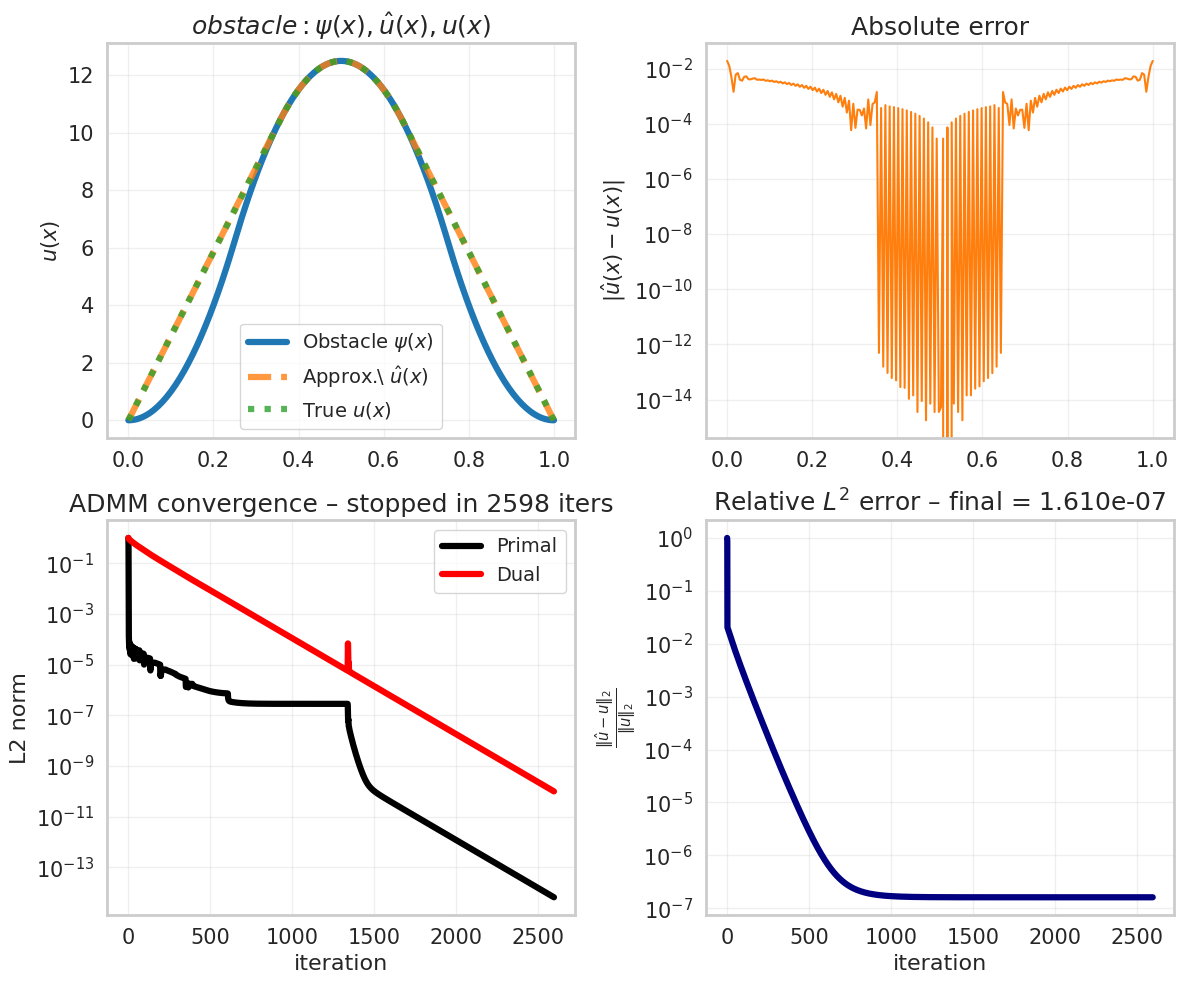

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. convenience ----------------------------------------------------
iterations = np.arange(len(prim))
abs_err    = np.abs(u_final - u_true)

# ── 2. Figure & style (publication-ready) -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
lw = 4.5                  # desired line width

# ── (1, 1) obstacle / approx / true -----------------------------------
ax = axes[0, 0]
ax.plot(x, psi,     lw=lw, label=r'Obstacle $\psi(x)$', linestyle='-',  color='tab:blue')
ax.plot(x, u_final, lw=lw, label=r'Approx.\ $\hat{u}(x)$', linestyle='--', color='tab:orange', alpha=0.8)
ax.plot(x, u_true,  lw=lw, label=r'True $u(x)$',       linestyle=':',  color='tab:green',  alpha=0.8)

ax.set_title(r'$obstacle:\psi(x), \hat{u}(x), u(x)$', fontsize=18)
ax.set_ylabel(r'$u(x)$', fontsize = 15);  ax.grid(alpha=0.3)
ax.legend(fontsize=14)

# ── (1, 2) absolute error ---------------------------------------------
ax = axes[0, 1]
ax.semilogy(x, abs_err, lw=1.5, label=r'$\hat{u}(x) - u(x)$', color = 'tab:orange', linestyle = '-')
ax.set_title('Absolute error', fontsize=18)
ax.set_ylabel(r'$ | \hat{u}(x) - u(x) |$', fontsize = 15)
ax.grid(alpha=0.3)

# ── (2, 1) ADMM residuals ---------------------------------------------
ax = axes[1, 0]
ax.semilogy(iterations, prim, lw=lw, label='Primal', color = 'black')
ax.semilogy(iterations, dual, lw=lw, label='Dual', color = 'red')
ax.set_title(f'ADMM convergence – stopped in {it_conv} iters', fontsize=18)
ax.set_xlabel('iteration');  ax.set_ylabel('L2 norm');  ax.grid(alpha=0.3)
ax.legend(fontsize=14)

# ── (2, 2) relative L2 error ------------------------------------------
ax = axes[1, 1]
ax.semilogy(iterations, l2, lw=lw, color = 'navy')
ax.set_title(f'Relative $L^2$ error – final = {l2[-1]:.3e}', fontsize=18)
ax.set_xlabel('iteration');
ax.set_ylabel(r'$\frac{ \| \hat{u} - u \|_{2}}{\| u \|_{2} }$', fontsize = 15)
ax.grid(alpha=0.3)

# ── 3. global tweaks ---------------------------------------------------
for ax in axes.flat:
    ax.tick_params(labelsize=15)
fig.tight_layout()



if problem == '1':
    plt.savefig('fig_obstacle1D_single_bump.png')
    files.download('fig_obstacle1D_single_bump.png')
elif problem == '2':
    plt.savefig('fig_obstacle1D_two_bump.png')
    files.download('fig_obstacle1D_two_bump.png')